# Fit and inspect individual events with LicketyFit

This notebook uses the production `batch_fit_driver.py` engines through `scripts/single_event_fit.py`. It does not contain a second fit implementation. The same event loaders, active-PMT rules, detector geometry, physics switches, seed bank, prompt cuts, likelihood, and optimizer are used here and in `run_wcte.py` / `run_wcsim.py`.

The workflow is: load a small event collection, inspect and plot one event, fit it, then compare PMT-by-PMT observations with the model prediction at the fitted parameters. The WCTE example comes first; WCSim follows later.

## 1. One-time repository setup

From the repository root, initialize the two direct runtime submodules. Do not use `--recursive`; LicketyFit does not use `analysis_tools`' nested submodules.

```bash
git submodule update --init analysis_tools Geometry
python3 -m pip install -r requirements.txt
```

Start Jupyter from either the repository root or `examples/`.

In [1]:
from pathlib import Path
from IPython.display import display
import sys
import pandas as pd
import matplotlib.pyplot as plt

working = Path.cwd().resolve()
REPO_ROOT = working if (working / 'scripts').is_dir() else working.parent
SCRIPTS = REPO_ROOT / 'scripts'
if not (SCRIPTS / 'batch_fit_driver.py').is_file():
    raise RuntimeError('Run this notebook from LicketyFit_official or its examples directory')
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from single_event_fit import WCTEConfig, WCSimConfig, SingleEventFitter, summarize_fit
from plot_event import plot_event

print('Repository:', REPO_ROOT)

Repository: /eos/home-i01/j/jrimmer/SWAN_projects/beam/LicketyFit_official


## 2. WCTE: choose the small set of settings that normally matters

This example obtains both events and the authoritative active-PMT list from run 2079. For a first interactive study, the important choices are the run, particle population/hypothesis, fit mode, likelihood, number of raw ROOT entries to scan, and number of selected events to retain.

`WCTEConfig` accepts every public option in `scripts/run_wcte.py`, using the same names in lowercase. Keep the notebook configuration short unless the study genuinely requires an advanced change.

In [2]:
wcte_config = WCTEConfig(
    run=2079,
    event_source='selection',
    good_pmt_source='run',
    particle_selection_label='muon',
    fit_particle='muon',
    fit_mode='full_length',
    likelihood_mode='charge_time',
    n_root_entries=2000,
    max_events_to_fit=20,
)
wcte_config

WCTEConfig(fit_mode='full_length', likelihood_mode='charge_time', n_root_entries=2000, max_events_to_fit=20, good_pmt_source='run')

Alternative authoritative PMT/event combinations are configured exactly as in `run_wcte.py`:

- user events + run mask: `event_source='file'`, `user_event_file=...`, `good_pmt_source='run'`, `run=...`;
- collaboration-selected events + user mask: `event_source='selection'`, `good_pmt_source='file'`, `good_pmt_file=...`;
- user events + user mask: set both sources to `'file'`.

For real WCTE data, the user/run list is the complete authoritative active set. The historical WCSim inactive-slot list is never applied.

In [3]:
# Optional discovery aid. This lists all public run_wcte.py settings; it does not change them.
#WCTEConfig.available_options()

## 3. WCTE: load a small selected-event collection

The call below uses the same `analysis_tools` DataLoader/BeamSelection adapter as the batch driver. `n_root_entries` limits raw entries inspected; `max_events_to_fit` limits events retained after selection. This step does not initialize the optical fitter yet.

In [4]:
wcte_fitter = SingleEventFitter(wcte_config)
wcte_events = wcte_fitter.load_events()
wcte_events

EventCollection(source='wcte', n_events=20)

In [5]:
pd.DataFrame([
    {
        'selected_index': i,
        'root_entry': event.metadata.get('source_root_entry_index'),
        'event_id': event.metadata.get('source_event_id'),
        'raw_hits': event.n_hits,
        'raw_charge_adc': event.total_charge,
    }
    for i, event in enumerate(wcte_events)
])

,selected_index,root_entry,event_id,raw_hits,raw_charge_adc
0,0,1,1,761,240149.0
1,1,32,32,7909,2903486.0
2,2,33,33,8361,3083323.0
3,3,39,39,2757,1082461.0
4,4,53,53,6679,2541200.0
5,5,85,85,3987,1240884.0
6,6,88,88,7613,2606971.0
7,7,96,96,6793,2392032.0
8,8,102,102,4762,1681858.0
9,9,186,186,10034,4072195.0


## 4. WCTE: select and plot an event before fitter preparation

This first display shows the selected loader output before LicketyFit's prompt-time cut, active-channel filtering, ADC-to-PE conversion, relative-efficiency treatment, and event time-reference shift.

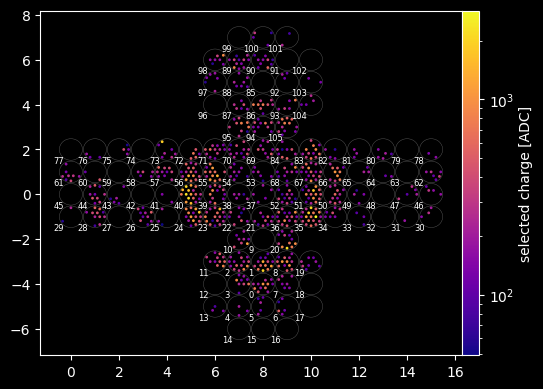

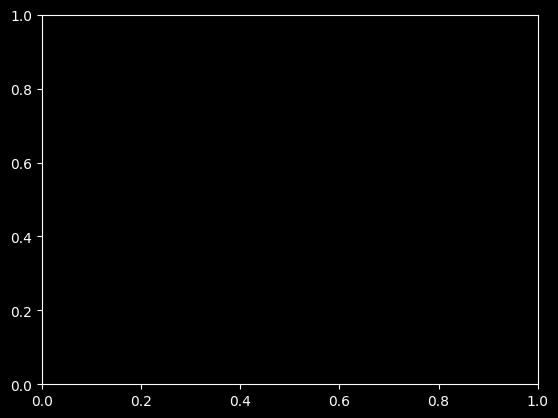

In [11]:
WCTE_EVENT_INDEX = 0
wcte_event = wcte_events[WCTE_EVENT_INDEX]
plot_event(wcte_event, quantity='charge', color_label='selected charge [ADC]',log_scale=True)
plt.show()

## 5. WCTE: fit the selected event

The first call initializes geometry, range/response tables, seeds, and the proxy library. Later events fitted with the same `wcte_fitter` reuse that state.

The current production fitter does **not** use Minuit. Its `minuit_valid` batch-output field is a historical compatibility alias. The compact output below therefore reports the real track-aligned optimizer, finite/accepted status, objective evaluations, retained seed candidates, optimized basins, candidate failures, history records, and wall time.

In [ ]:
wcte_result = wcte_fitter.fit(wcte_event)
summarize_fit(wcte_result)

## 6. WCTE: inspect post-cut PE and timing closure

`observed_pe` and `observed_time_ns` are exactly the PMT-aligned observables handed to the likelihood after prompt and active-PMT cuts. WCTE times are in the fitted event-relative reference; the removed input-time offset is stored in `wcte_result.raw_result['global_time_offset_ns']`.

`expected_pe` and `expected_time_ns` are evaluated at the final estimate using the selected production objective, including cosmic clipping, charge normalization, and any selected explicit mPMT-boundary subclass. The timing likelihood predicts a source-resolved first-arrival distribution rather than one scalar; `expected_time_ns` is its PMT-wise mean before zero-mean transit-time smearing. For charge-only fits, these times are diagnostics and did not influence the minimum.

In [ ]:
wcte_pmt_table = wcte_result.pmt_table(hit_only=True)
wcte_pmt_table.head(20)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(wcte_result.observed_pe, wcte_result.expected_pe, s=8, alpha=0.7)
limit = max(wcte_result.observed_pe.max(), wcte_result.expected_pe.max(), 1.0)
axes[0].plot([0, limit], [0, limit], 'k--', linewidth=1)
axes[0].set(xlabel='observed PE after cuts', ylabel='expected PE at estimate')
timed = wcte_result.timing_comparison_mask
axes[1].scatter(
    wcte_result.expected_time_ns[timed],
    wcte_result.observed_time_ns[timed],
    s=8, alpha=0.7,
)
axes[1].set(xlabel='expected time [ns]', ylabel='observed time [ns]')
fig.tight_layout()

In [ ]:
plot_event(wcte_result, quantity='observed_pe', color_label='observed PE after cuts')
plot_event(wcte_result, quantity='expected_pe', color_label='expected PE at fit')

To fit another already-loaded event, only the event-specific preparation and fit are repeated:

```python
next_result = wcte_fitter.fit(wcte_events[1])
summarize_fit(next_result)
```

# WCSim example

The WCSim workflow is intentionally the same. Set one NPZ path, load a small interval, display a raw digitized event, fit it, and inspect post-cut model closure. WCSim keeps its historical detector-mode inactive-slot policy; that policy is separate from the authoritative WCTE good-PMT list.

In [ ]:
WCSIM_FILE = Path('/path/to/digitized_wcsim_events.npz')

wcsim_config = WCSimConfig(
    input_file=str(WCSIM_FILE),
    n_events=10,
    event_start_index=0,
    fit_particle='muon',
    fit_mode='cosmic',
    likelihood_mode='charge_time',
    energy_label_mev=300.0,  # metadata/optional seed hint, not event truth
)
wcsim_config

`WCSimConfig` accepts every public option in `scripts/run_wcsim.py`. Optional `AllSecondaries` truth remains diagnostic-only: set `use_truth_root=True` and `truth_root_file=...` to attach the selected event's active-water truth record without passing it to the likelihood.

In [ ]:
WCSimConfig.available_options()

In [ ]:
if WCSIM_FILE.is_file():
    wcsim_fitter = SingleEventFitter(wcsim_config)
    wcsim_events = wcsim_fitter.load_events()
    display(pd.DataFrame([
        {'input_index': e.source_index, 'digitized_hits': e.n_hits, 'total_charge_pe': e.total_charge}
        for e in wcsim_events
    ]))
else:
    wcsim_fitter = None
    wcsim_events = None
    print('Set WCSIM_FILE to run the WCSim section.')

In [ ]:
if wcsim_events is not None:
    WCSIM_EVENT_INDEX = 0
    wcsim_event = wcsim_events[WCSIM_EVENT_INDEX]
    plot_event(wcsim_event, quantity='charge', color_label='digitized charge [PE]')

In [ ]:
if wcsim_events is not None:
    wcsim_result = wcsim_fitter.fit(wcsim_event)
    summarize_fit(wcsim_result)

In [ ]:
if wcsim_events is not None:
    display(wcsim_result.pmt_table(hit_only=True).head(20))
    plot_event(wcsim_result, quantity='observed_pe', color_label='observed PE after cuts')
    plot_event(wcsim_result, quantity='expected_pe', color_label='expected PE at fit')
    plot_event(wcsim_result, quantity='observed_time', color_label='observed time [ns]')
    plot_event(wcsim_result, quantity='expected_time', color_label='model first-arrival mean [ns]')

In [ ]:
if wcsim_events is not None:
    timed = wcsim_result.timing_comparison_mask
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].scatter(wcsim_result.observed_pe, wcsim_result.expected_pe, s=8, alpha=0.7)
    axes[0].set(xlabel='observed PE after cuts', ylabel='expected PE at estimate')
    axes[1].scatter(wcsim_result.expected_time_ns[timed], wcsim_result.observed_time_ns[timed], s=8, alpha=0.7)
    axes[1].set(xlabel='model first-arrival mean [ns]', ylabel='observed time [ns]')
    fig.tight_layout()

## What to transfer back to a batch run

Once an event study is satisfactory, copy the corresponding configuration values into `scripts/run_wcte.py` or `scripts/run_wcsim.py`. Do not transfer notebook-only mechanics: single-event execution is always serial, does not create batch checkpoints, and keeps detailed diagnostics in memory rather than writing a batch output dictionary.